Total countries: 158
       Country          Region  Happiness Rank  Happiness Score  \
0  Switzerland  Western Europe               1            7.587   
1      Iceland  Western Europe               2            7.561   
2      Denmark  Western Europe               3            7.527   
3       Norway  Western Europe               4            7.522   
4       Canada   North America               5            7.427   

   Standard Error  Economy (GDP per Capita)   Family  \
0         0.03411                   1.39651  1.34951   
1         0.04884                   1.30232  1.40223   
2         0.03328                   1.32548  1.36058   
3         0.03880                   1.45900  1.33095   
4         0.03553                   1.32629  1.32261   

   Health (Life Expectancy)  Freedom  Trust (Government Corruption)  \
0                   0.94143  0.66557                        0.41978   
1                   0.94784  0.62877                        0.14145   
2                   0.8746

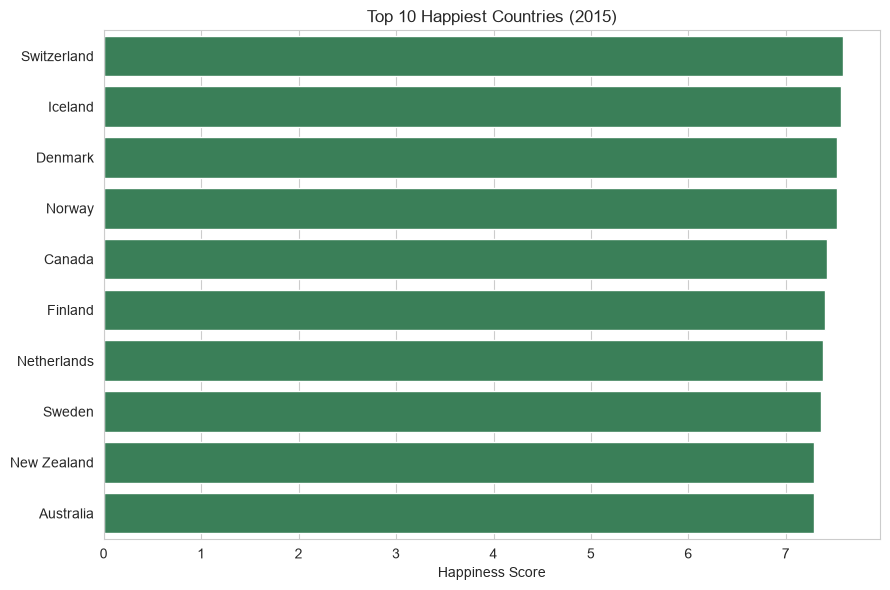

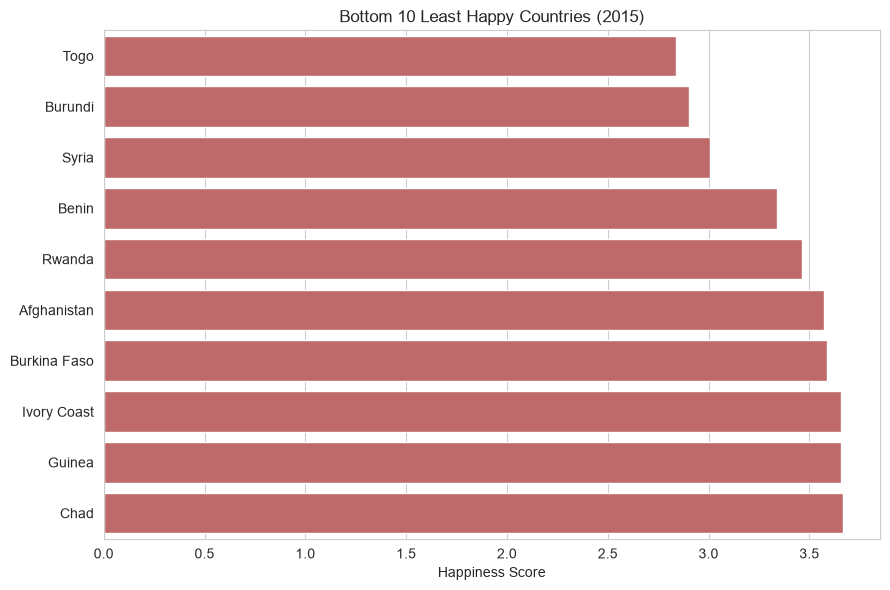

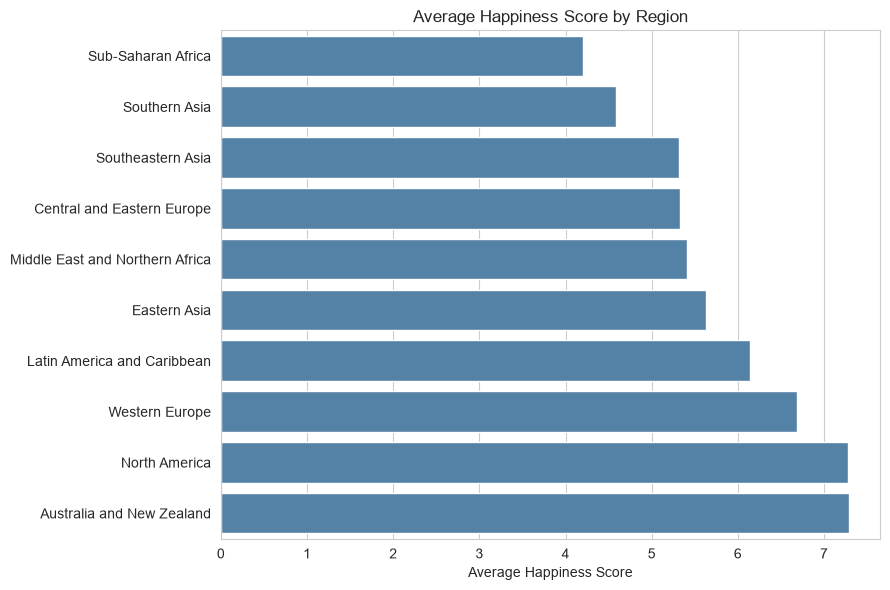

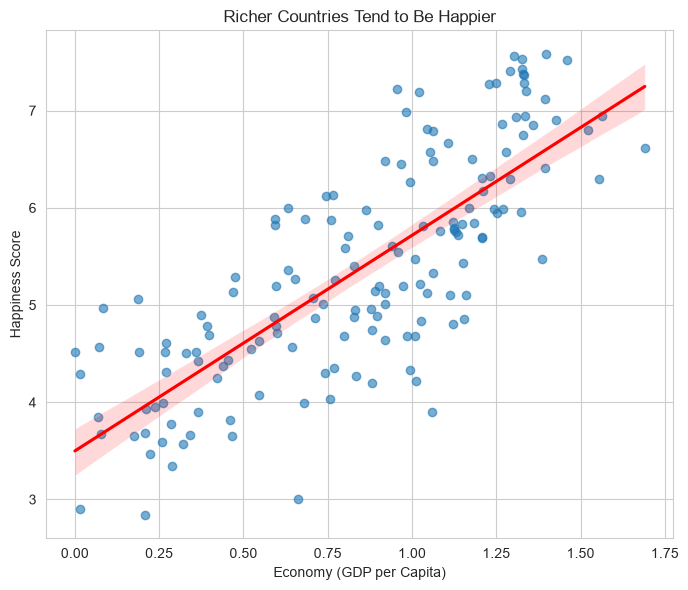

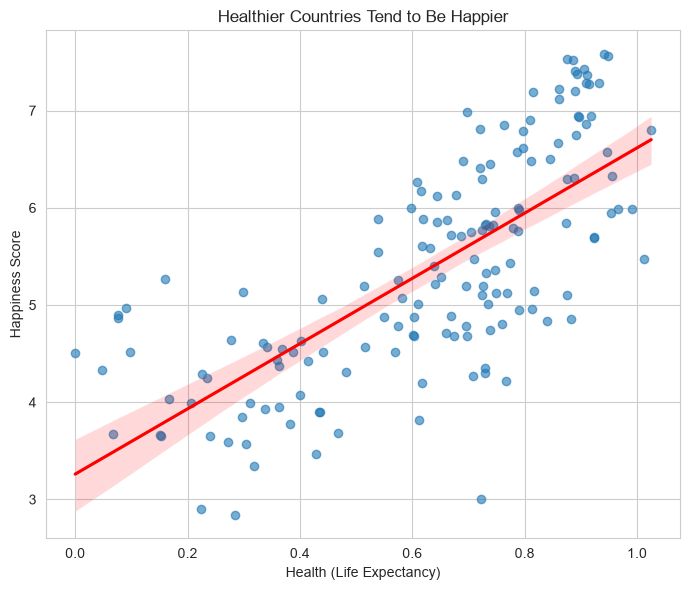

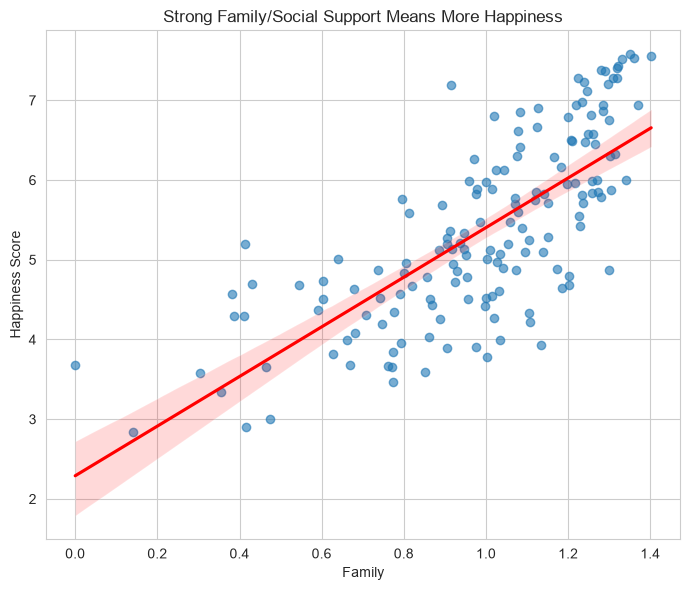

In [7]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")


class HappinessAnalyzer:

    def __init__(self, filepath):
        self.df = pd.read_csv(filepath)

    def show_summary(self):
        print("Total countries:", len(self.df))
        print(self.df.head())

    def plot_top10(self):
        top10 = self.df.nsmallest(10, "Happiness Rank")

        plt.figure(figsize=(9, 6))
        sns.barplot(data=top10, x="Happiness Score", y="Country", color="seagreen")
        plt.title("Top 10 Happiest Countries (2015)")
        plt.xlabel("Happiness Score")
        plt.ylabel("")
        plt.tight_layout()
        plt.savefig("1_top10_happiest.png")
        plt.show()

    def plot_bottom10(self):
        bottom10 = self.df.nlargest(10, "Happiness Rank")

        plt.figure(figsize=(9, 6))
        sns.barplot(data=bottom10, x="Happiness Score", y="Country", color="indianred")
        plt.title("Bottom 10 Least Happy Countries (2015)")
        plt.xlabel("Happiness Score")
        plt.ylabel("")
        plt.tight_layout()
        plt.savefig("2_bottom10_least_happy.png")
        plt.show()

    def plot_region_average(self):
        region_avg = self.df.groupby("Region")["Happiness Score"].mean().sort_values()

        plt.figure(figsize=(9, 6))
        sns.barplot(x=region_avg.values, y=region_avg.index, color="steelblue")
        plt.title("Average Happiness Score by Region")
        plt.xlabel("Average Happiness Score")
        plt.ylabel("")
        plt.tight_layout()
        plt.savefig("3_region_average.png")
        plt.show()

    def plot_vs_happiness(self, column, filename, title):
        plt.figure(figsize=(7, 6))
        sns.regplot(data=self.df, x=column, y="Happiness Score",
                    scatter_kws={"alpha": 0.6}, line_kws={"color": "red"})
        plt.title(title)
        plt.xlabel(column)
        plt.ylabel("Happiness Score")
        plt.tight_layout()
        plt.savefig(filename)
        plt.show()


# ---- run the analysis ----
analyzer = HappinessAnalyzer("2015.csv")

analyzer.show_summary()
analyzer.plot_top10()
analyzer.plot_bottom10()
analyzer.plot_region_average()

analyzer.plot_vs_happiness("Economy (GDP per Capita)", "4_gdp_vs_happiness.png",
                            "Richer Countries Tend to Be Happier")
analyzer.plot_vs_happiness("Health (Life Expectancy)", "5_health_vs_happiness.png",
                            "Healthier Countries Tend to Be Happier")
analyzer.plot_vs_happiness("Family", "6_family_vs_happiness.png",
                            "Strong Family/Social Support Means More Happiness")